In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
# Load raw data as pandas dataframes
calendar = pd.read_csv('../data/raw/calendar.csv')
sales_eval = pd.read_csv('../data/raw/sales_train_evaluation.csv')
sales_val = pd.read_csv('../data/raw/sales_train_validation.csv')
sell_prices = pd.read_csv('../data/raw/sell_prices.csv')

In [3]:
print('CALENDAR')
print('==========================================================')
print(calendar.info())
print('\nSALES TRAIN EVALUATION')
print('==========================================================')
print(sales_eval.info())
print('\nSALES TRAIN VALIDATION')
print('==========================================================')
print(sales_val.info())
print('==========================================================')
print('\nSALES PRICES')
print(sell_prices.info())

CALENDAR
<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB
None

SALES TRAIN EVALUATION
<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 452.9 MB
None

SALE

In [4]:
print(calendar.shape)
calendar.head()

(1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [5]:
calendar.columns.to_list()

['date',
 'wm_yr_wk',
 'weekday',
 'wday',
 'month',
 'year',
 'd',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2',
 'snap_CA',
 'snap_TX',
 'snap_WI']

In [6]:
print(sell_prices.shape)
sell_prices.head()

(6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [7]:
sell_prices.columns.to_list()

['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

In [8]:
print(sales_eval.shape)
sales_eval.head()

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


#### The sales_eval table will be converted from wide to long format to enable advanced visualization and simplify filtering and grouping. Long format tables also make joining and modeling easier. 




In [9]:
# wide format to long format
sales_melted = pd.melt(sales_eval, 
                       id_vars =['id', 'item_id', 'dept_id','cat_id','store_id','state_id'], # colmuns that will not be changed
                       # the rest of the columns will be melted
                       var_name = 'days', # name of the new melted column
                       value_name = 'sales' # sales per day
                      )  

In [10]:
sales_melted.tail(10) 

,id,item_id,dept_id,cat_id,store_id,state_id,days,sales
59181080,FOODS_3_818_WI_3_evaluation,FOODS_3_818,FOODS_3,FOODS,WI_3,WI,d_1941,0
59181081,FOODS_3_819_WI_3_evaluation,FOODS_3_819,FOODS_3,FOODS,WI_3,WI,d_1941,1
59181082,FOODS_3_820_WI_3_evaluation,FOODS_3_820,FOODS_3,FOODS,WI_3,WI,d_1941,1
59181083,FOODS_3_821_WI_3_evaluation,FOODS_3_821,FOODS_3,FOODS,WI_3,WI,d_1941,4
59181084,FOODS_3_822_WI_3_evaluation,FOODS_3_822,FOODS_3,FOODS,WI_3,WI,d_1941,4
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0
59181089,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,d_1941,1


In [11]:
# renaming calendar column d to days to merge tables
calendar.rename(columns={'d':'days'}, inplace = True)
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,days,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [12]:
# merging long format sales data with calendar
df = pd.merge(sales_melted, calendar, on ='days', how = 'left')
df.head(2)

,id,item_id,dept_id,cat_id,store_id,state_id,days,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [13]:
merged_df = pd.merge(df, sell_prices, on =['store_id', 'item_id','wm_yr_wk'], how = 'left')
merged_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,days,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [14]:
merged_df.columns.to_list()

['id',
 'item_id',
 'dept_id',
 'cat_id',
 'store_id',
 'state_id',
 'days',
 'sales',
 'date',
 'wm_yr_wk',
 'weekday',
 'wday',
 'month',
 'year',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2',
 'snap_CA',
 'snap_TX',
 'snap_WI',
 'sell_price']

In [15]:
#overall summary
merged_df[['sales', 'sell_price']].describe()

,sales,sell_price
count,5.918109e+07,4.688168e+07
mean,1.130888e+00,4.409438e+00
std,3.870038e+00,3.406106e+00
min,0.000000e+00,1.000000e-02
25%,0.000000e+00,2.180000e+00
50%,0.000000e+00,3.470000e+00
75%,1.000000e+00,5.840000e+00
max,7.630000e+02,1.073200e+02


In [16]:
# sales by category department 
merged_df.groupby('cat_id')['sales'].agg(['mean','median','std','sum','max'])

,mean,median,std,sum,max
cat_id,,,,,
FOODS,1.646427,0.0,5.144377,45922427,763
HOBBIES,0.569058,0.0,2.036739,6240656,294
HOUSEHOLD,0.726498,0.0,2.087060,14764090,626


In [17]:
# Min, max, and spread of prices per category
merged_df.groupby('cat_id')['sell_price'].agg(['min', 'max', 'mean', 'median', 'std'])

,min,max,mean,median,std
cat_id,,,,,
FOODS,0.01,19.48,3.248950,2.68,2.130764
HOBBIES,0.01,30.98,5.329613,3.97,4.821907
HOUSEHOLD,0.01,107.32,5.465685,4.94,3.373758


In [18]:
sns.set_theme(palette = 'muted', font_scale = 1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

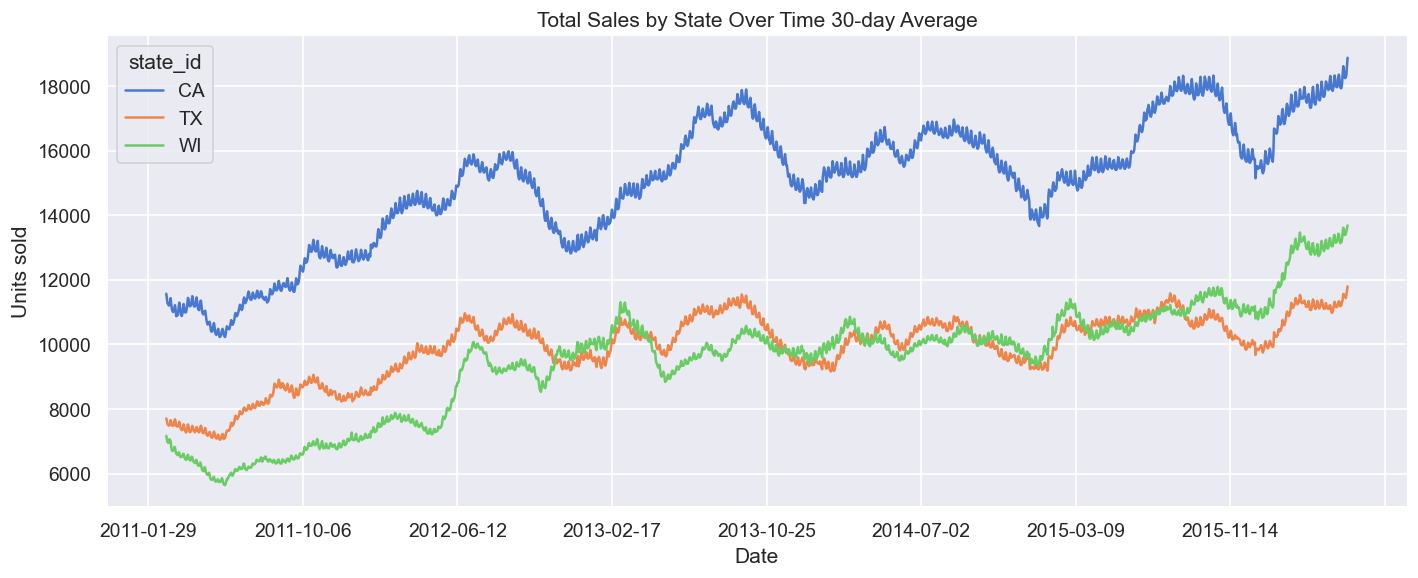

In [19]:
store_sales = (
    merged_df.groupby(['date', 'state_id'])['sales']
    .sum()
    .unstack()
    .rolling(30).mean()   # 30-day rolling avg removes the daily spikes
)

plt.figure(figsize=(12, 5))
store_sales.plot(ax=plt.gca())

plt.title("Total Sales by State Over Time 30-day Average")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

In [20]:
merged_df['date'] = pd.to_datetime(merged_df['date'])

In [21]:
# function for continuous features
def continuous_quality_report(df, features):
    #Table Continuous features quality report
    rows=[]
    total = len(df)
    for col in features:
        c= df[col].dropna() # drop null values before summary statistics
        null_count = df[col].isna().sum()
        rows.append({
            'Feature':col, 
            'Count': total, # total rows in df per feature
            '% Missing': round(null_count/total *100, 1), # total missing values per feature
            'Cardinality': df[col].nunique(), # number of unique values 
            # sumary statistics 
            'Min': round(c.min(), 2),
            '1st Quartile': round(c.quantile(0.25), 2),
            'Mean': round(c.mean(),2),
            'Median': round(c.median(),2),
            '3rd Quartile': round(c.quantile(0.75),2),
            'Max': round(c.max(),2),
            'Standard Dev': round(c.std(),2,)
        })
    return pd.DataFrame(rows).set_index('Feature')


# function for categorical features

def categorical_quality_report(df, features):
    rows = []
    total = len(df)

    for col in features:
        null_count = df[col].isna().sum()
        # value_counts() returns each unique value sorted by frequency descending, dropna=True removes nulls
        counts = df[col].value_counts(dropna = True)
        mode_val = counts.index[0] if len(counts) > 0 else None # .index[0] gets the value category name 
        mode_freq = counts.iloc[0] if len(counts) > 0 else 0    # .iloc[0]  gets its count 
        mode_pct = round(mode_freq / total * 100,1)
        
        # same logic but index position 1 instead of 0
        # when a column has only one unique value and position 1 doesn't exist
        mode2_val  = counts.index[1] if len(counts) > 1 else None
        mode2_freq = counts.iloc[1]  if len(counts) > 1 else 0
        mode2_pct  = round(mode2_freq / total * 100, 1)

        rows.append({
            'Feature': col,
            'Count': total,
            '% Missing': round(null_count/total * 100, 1),
            'Cardinality':          df[col].nunique(),
            'Mode':           mode_val,
            'Mode Freq.':     mode_freq,
            'Mode %':         mode_pct,
            '2nd Mode':       mode2_val,
            '2nd Mode Freq.': mode2_freq,
            '2nd Mode %':     mode2_pct,
            
        })

    return pd.DataFrame(rows).set_index('Feature')


continuous_features = [
    'sales',        # units sold per item per day (target variable)
    'sell_price',   # weekly item price
    'wm_yr_wk',     # walmart internal week ID 
    'wday',         # day of week as integer
    'month',        # month number 
    'year',         # year 2011–2016
    'snap_CA',      # binary: 1 if SNAP benefits active 
    'snap_TX',      
    'snap_WI',      
]
categorical_features = [
    'id',
    'item_id',
    'cat_id',        # product category: FOODS, HOBBIES, HOUSEHOLD
    'dept_id',       # department: e.g. FOODS_1, FOODS_2 ...
    'store_id',      # store: CA_1... (10 stores)
    'state_id',      # state: CA, TX, WI
    'weekday',       # day of week as string: Monday through Sunday
    'event_name_1',  # holiday/event name 
    'event_type_1',  # event category: Religious, National, Sporting, Cultural
    'event_name_2',
    'event_type_2',
]

 # 'days',
 # 'date',
 

In [22]:
calendar_features =['date',
 'wm_yr_wk',
 'weekday',
 'wday',
 'month',
 'year',
 'days',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2',
 'snap_CA',
 'snap_TX',
 'snap_WI']
calendar_report  = categorical_quality_report(calendar, calendar_features)
display(calendar_report.style.set_caption("Data Quality Report for Calendar"))

,Count,% Missing,Cardinality,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
Feature,,,,,,,,,
date,1969,0.000000,1969,2011-01-29,1,0.100000,2011-01-30,1,0.100000
wm_yr_wk,1969,0.000000,282,11101,7,0.400000,11102,7,0.400000
weekday,1969,0.000000,7,Saturday,282,14.300000,Sunday,282,14.300000
wday,1969,0.000000,7,1,282,14.300000,2,282,14.300000
month,1969,0.000000,12,3,186,9.400000,5,186,9.400000
year,1969,0.000000,6,2012,366,18.600000,2013,365,18.500000
days,1969,0.000000,1969,d_1,1,0.100000,d_2,1,0.100000
event_name_1,1969,91.800000,30,SuperBowl,6,0.300000,ValentinesDay,6,0.300000
event_type_1,1969,91.800000,4,Religious,55,2.800000,National,52,2.600000


In [23]:
# Data quality report for sell price table
sell_price_cat = ['store_id', 'item_id', 'wm_yr_wk',]
sell_price_cont = ['sell_price']

price_cat_report  = categorical_quality_report(sell_prices, sell_price_cat)
display(price_cat_report.style.set_caption("Data Quality Report Categorical Features (Sell Price)"))

price_cont_report = continuous_quality_report(sell_prices, sell_price_cont)
display(price_cont_report.style.set_caption("Data Quality Report Continuous Features (Sell Price)"))

,Count,% Missing,Cardinality,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
Feature,,,,,,,,,
store_id,6841121,0.000000,10,TX_2,701214,10.200000,TX_1,699796,10.200000
item_id,6841121,0.000000,3049,HOBBIES_1_010,2820,0.000000,HOBBIES_1_022,2820,0.000000
wm_yr_wk,6841121,0.000000,282,11603,30490,0.400000,11604,30490,0.400000


,Count,% Missing,Cardinality,Min,1st Quartile,Mean,Median,3rd Quartile,Max,Standard Dev
Feature,,,,,,,,,,
sell_price,6841121,0.000000,1048,0.010000,2.180000,4.410000,3.470000,5.840000,107.320000,3.410000


In [24]:
sales_col = sales_eval.columns.to_list()

In [25]:
# Data quality report for sales wide format
sales_cont_report = categorical_quality_report(sales_eval, sales_col)
display(sales_cont_report.style.set_caption("Data Quality Report Continuous Features (Sales)"))

,Count,% Missing,Cardinality,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
Feature,,,,,,,,,
id,30490,0.000000,30490,HOBBIES_1_001_CA_1_evaluation,1,0.000000,HOBBIES_1_002_CA_1_evaluation,1,0.000000
item_id,30490,0.000000,3049,HOBBIES_1_001,10,0.000000,HOBBIES_1_002,10,0.000000
dept_id,30490,0.000000,7,FOODS_3,8230,27.000000,HOUSEHOLD_1,5320,17.400000
cat_id,30490,0.000000,3,FOODS,14370,47.100000,HOUSEHOLD,10470,34.300000
store_id,30490,0.000000,10,CA_1,3049,10.000000,CA_2,3049,10.000000
state_id,30490,0.000000,3,CA,12196,40.000000,TX,9147,30.000000
d_1,30490,0.000000,84,0,23511,77.100000,1,2385,7.800000
d_2,30490,0.000000,82,0,23610,77.400000,1,2298,7.500000
d_3,30490,0.000000,72,0,24500,80.400000,1,2284,7.500000


In [26]:
# Data quality report for sales long format
sales_cat = ['id', 'item_id','dept_id', 'cat_id', 'store_id', 'state_id', 'days']
sales_cont = ['sales']

sales_cat_long_report  = categorical_quality_report(sales_melted, sales_cat)
display(sales_cat_long_report.style.set_caption("Data Quality Report Categorical Features (Sales)"))

sales_cont_long_report = continuous_quality_report(sales_melted, sales_cont)
display(sales_cont_long_report.style.set_caption("Data Quality Report Continuous Features (Sales)"))

,Count,% Missing,Cardinality,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
Feature,,,,,,,,,
id,59181090,0.000000,30490,HOBBIES_1_001_CA_1_evaluation,1941,0.000000,HOBBIES_1_002_CA_1_evaluation,1941,0.000000
item_id,59181090,0.000000,3049,HOBBIES_1_001,19410,0.000000,HOBBIES_1_002,19410,0.000000
dept_id,59181090,0.000000,7,FOODS_3,15974430,27.000000,HOUSEHOLD_1,10326120,17.400000
cat_id,59181090,0.000000,3,FOODS,27892170,47.100000,HOUSEHOLD,20322270,34.300000
store_id,59181090,0.000000,10,CA_1,5918109,10.000000,CA_2,5918109,10.000000
state_id,59181090,0.000000,3,CA,23672436,40.000000,TX,17754327,30.000000
days,59181090,0.000000,1941,d_1,30490,0.100000,d_2,30490,0.100000


,Count,% Missing,Cardinality,Min,1st Quartile,Mean,Median,3rd Quartile,Max,Standard Dev
Feature,,,,,,,,,,
sales,59181090,0.000000,419,0,0.000000,1.130000,0.000000,1.000000,763,3.870000


# Data Quality Report for ABT (Merged Data)

In [27]:
# display reports
cont_report = continuous_quality_report(merged_df, continuous_features)
cat_report  = categorical_quality_report(merged_df, categorical_features)

display(cont_report.style.set_caption("Data Quality Report Continuous Features"))
display(cat_report.style.set_caption("Data Quality Report Categorical Features"))


,Count,% Missing,Cardinality,Min,1st Quartile,Mean,Median,3rd Quartile,Max,Standard Dev
Feature,,,,,,,,,,
sales,59181090,0.000000,419,0.000000,0.000000,1.130000,0.000000,1.000000,763.000000,3.870000
sell_price,59181090,20.800000,1036,0.010000,2.180000,4.410000,3.470000,5.840000,107.320000,3.410000
wm_yr_wk,59181090,0.000000,278,11101.000000,11218.000000,11343.170000,11335.000000,11451.000000,11617.000000,152.860000
wday,59181090,0.000000,7,1.000000,2.000000,4.000000,4.000000,6.000000,7.000000,2.000000
month,59181090,0.000000,12,1.000000,3.000000,6.330000,6.000000,9.000000,12.000000,3.440000
year,59181090,0.000000,6,2011.000000,2012.000000,2013.250000,2013.000000,2015.000000,2016.000000,1.560000
snap_CA,59181090,0.000000,2,0.000000,0.000000,0.330000,0.000000,1.000000,1.000000,0.470000
snap_TX,59181090,0.000000,2,0.000000,0.000000,0.330000,0.000000,1.000000,1.000000,0.470000
snap_WI,59181090,0.000000,2,0.000000,0.000000,0.330000,0.000000,1.000000,1.000000,0.470000


,Count,% Missing,Cardinality,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
Feature,,,,,,,,,
id,59181090,0.000000,30490,HOBBIES_1_001_CA_1_evaluation,1941,0.000000,HOBBIES_1_002_CA_1_evaluation,1941,0.000000
item_id,59181090,0.000000,3049,HOBBIES_1_001,19410,0.000000,HOBBIES_1_002,19410,0.000000
cat_id,59181090,0.000000,3,FOODS,27892170,47.100000,HOUSEHOLD,20322270,34.300000
dept_id,59181090,0.000000,7,FOODS_3,15974430,27.000000,HOUSEHOLD_1,10326120,17.400000
store_id,59181090,0.000000,10,CA_1,5918109,10.000000,CA_2,5918109,10.000000
state_id,59181090,0.000000,3,CA,23672436,40.000000,TX,17754327,30.000000
weekday,59181090,0.000000,7,Saturday,8476220,14.300000,Sunday,8476220,14.300000
event_name_1,59181090,91.900000,30,SuperBowl,182940,0.300000,ValentinesDay,182940,0.300000
event_type_1,59181090,91.900000,4,Religious,1646460,2.800000,National,1554990,2.600000


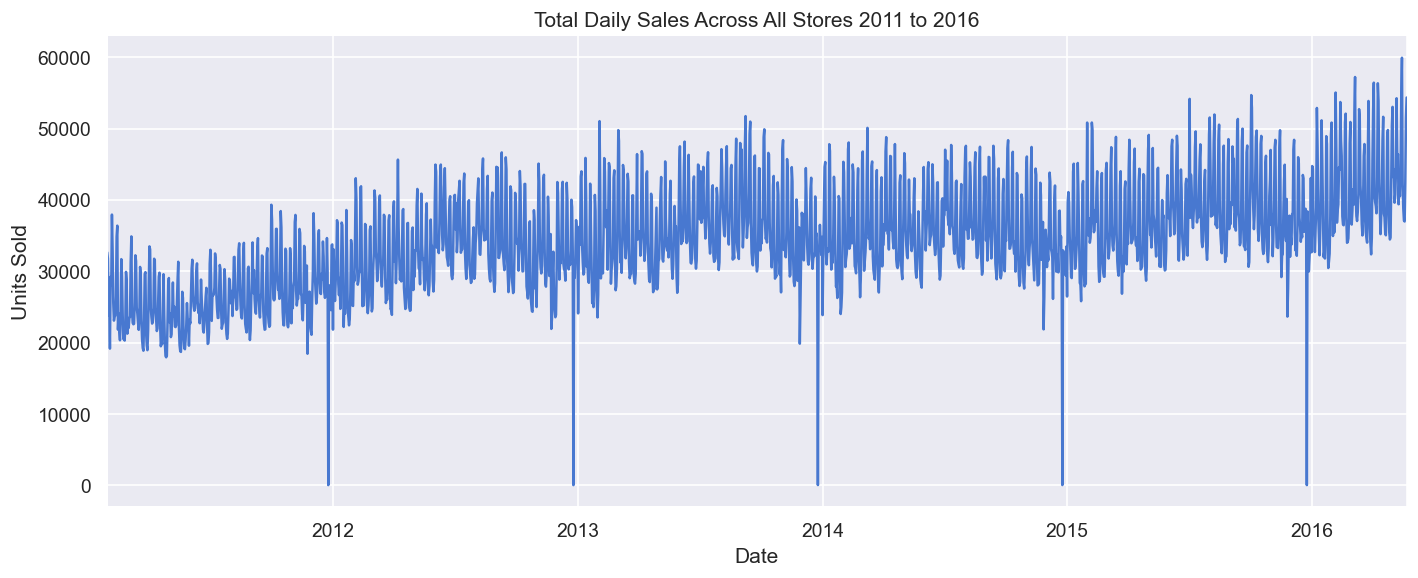

In [28]:
# group by date and sum all sales accross all items and stores
total_sales = merged_df.groupby('date')['sales'].sum()
plt.figure(figsize = (12, 5))
total_sales.plot()
plt.title('Total Daily Sales Across All Stores 2011 to 2016')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

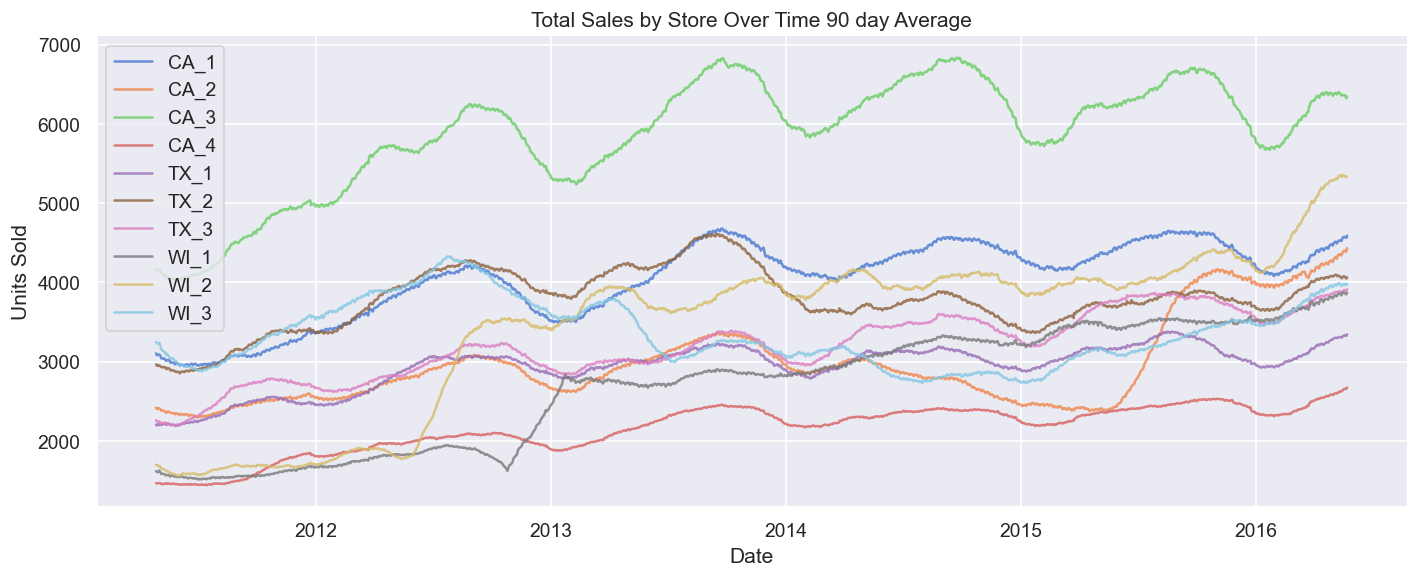

In [29]:
merged_df['date']= pd.to_datetime(merged_df['date'])
store_list = merged_df['store_id'].unique()

plt.figure(figsize = (12, 5))
  
# filter to one store at a time, group by date, sum sale, 90 day average to smooth the trend

for store in store_list:
    store_daily = (
        merged_df[merged_df['store_id'] == store]
        .groupby('date')['sales'].sum()
        .sort_index()
        .rolling(90).mean()
    )
    plt.plot(store_daily.index, store_daily.values, alpha= 0.8, label= store)

plt.title('Total Sales by Store Over Time 90 day Average')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend(store_list)
plt.tight_layout()
plt.show()

CA_3 is the strongest-performing store, diverging from the rest of the California stores around 2013 and continuing to extend its lead through 2016. In contrast, CA_4 consistently records the lowest sales in the state, indicating that store-level factors are more important than geography alone. Texas stores are closely clustered, indicating very similar performance patterns across that market, while Wisconsin stores also show consistency but at a lower overall sales level than Texas. 
Overall, these patterns highlight the importance of including store-level identifiers in the model. Aggregating across stores risks underrepresenting high performers such as CA_3.

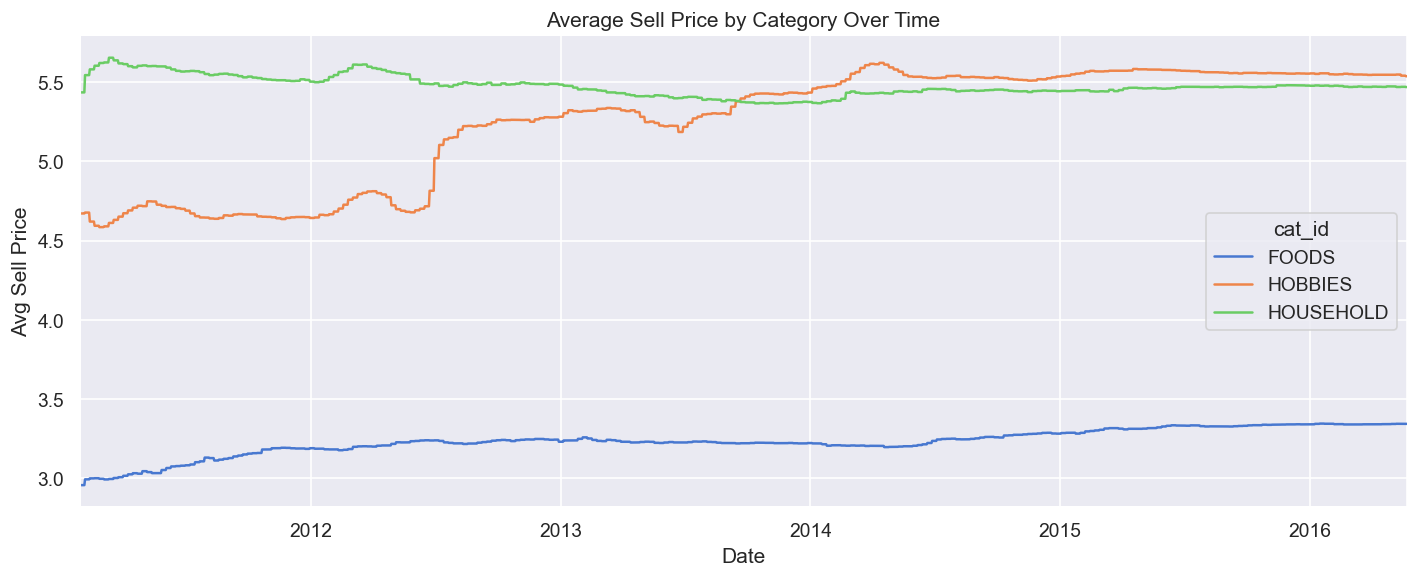

In [30]:
# group by date and category, take the mean price for each combination unstack pivots cat_id into separate columns: FOODS, HOBBIES, HOUSEHOLD
prices_by_cat = (
    merged_df.groupby(['date', 'cat_id'])['sell_price']
    .mean()
    .unstack()
)

plt.figure(figsize=(12, 5))
prices_by_cat.plot(ax=plt.gca())
plt.title('Average Sell Price by Category Over Time')
plt.xlabel('Date')
plt.ylabel('Avg Sell Price')
plt.tight_layout()
plt.show()


Prices remain largely stable from 2011 to 2016 across all three product categories. Household items have the highest average prices, followed by Hobbies, while Foods remain the least expensive. Aside from a small increase in Hobby prices around 2013, there is little variation over time. This stability suggests that rising prices are not responsible for the increase in sales growth trend observed in previous charts. The growth in units sold is more likely to reflect genuine increases in demand. 

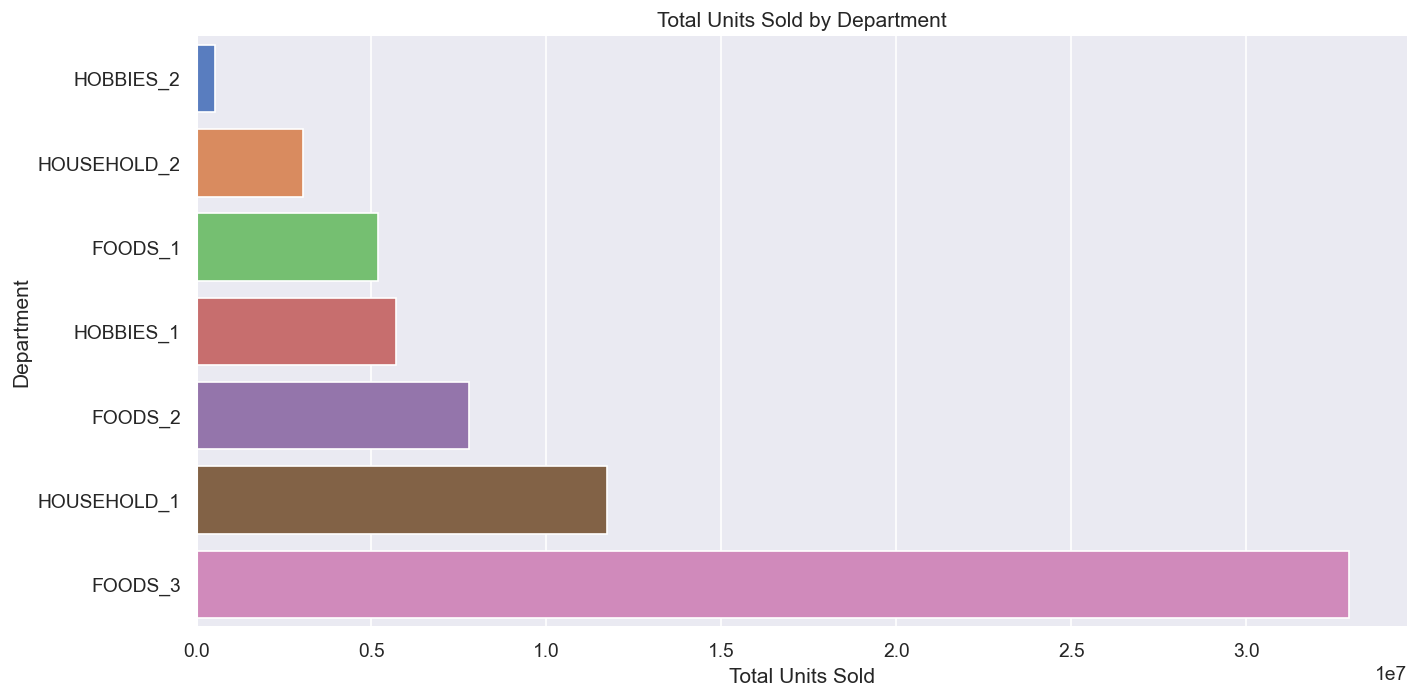

In [31]:
# sum all sales for each department across the entire dataset

dept_sales = (
    merged_df.groupby('dept_id')['sales']
    .sum()
    .sort_values(ascending=True) #sort ascending
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=dept_sales, x = 'sales', y = 'dept_id',hue = 'dept_id',legend = False)

plt.title('Total Units Sold by Department')
plt.xlabel('Total Units Sold')
plt.ylabel('Department')
plt.tight_layout()
plt.show()


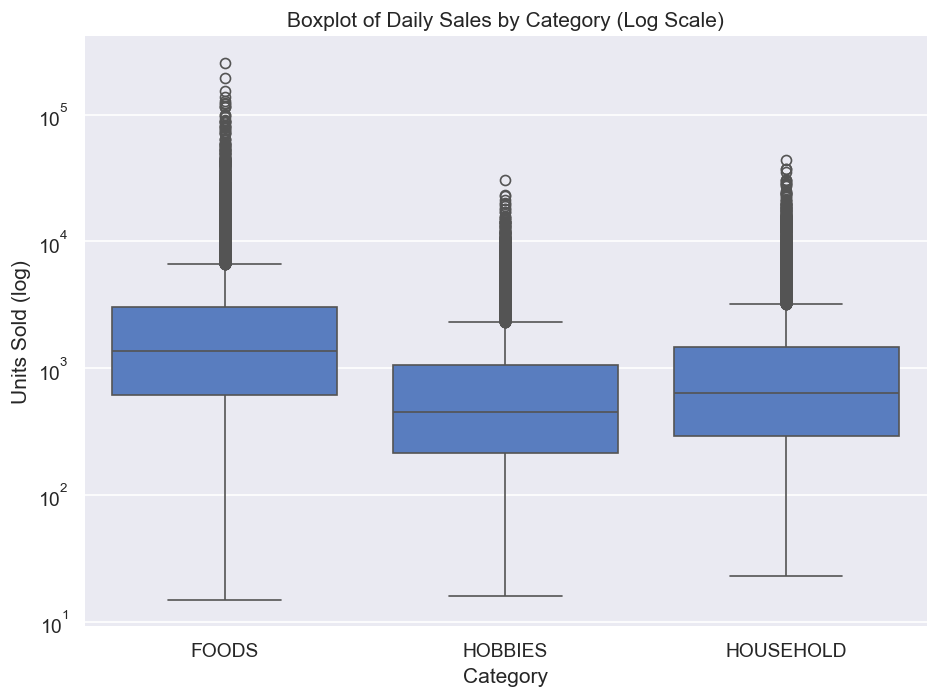

In [32]:
# sum all daily sales for each item-store combination
total_sales_per_item = (
    merged_df.groupby(['item_id', 'store_id', 'cat_id'])['sales']
    .sum()
    .reset_index()
    .rename(columns = {'sales':'total_sales'}))

plt.figure(figsize=(8,6))

sns.boxplot(data=total_sales_per_item, x = 'cat_id', y = 'total_sales')

plt.yscale('log')
plt.title('Boxplot of Daily Sales by Category (Log Scale)')
plt.xlabel('Category')
plt.ylabel('Units Sold (log)')
plt.tight_layout()
plt.show()

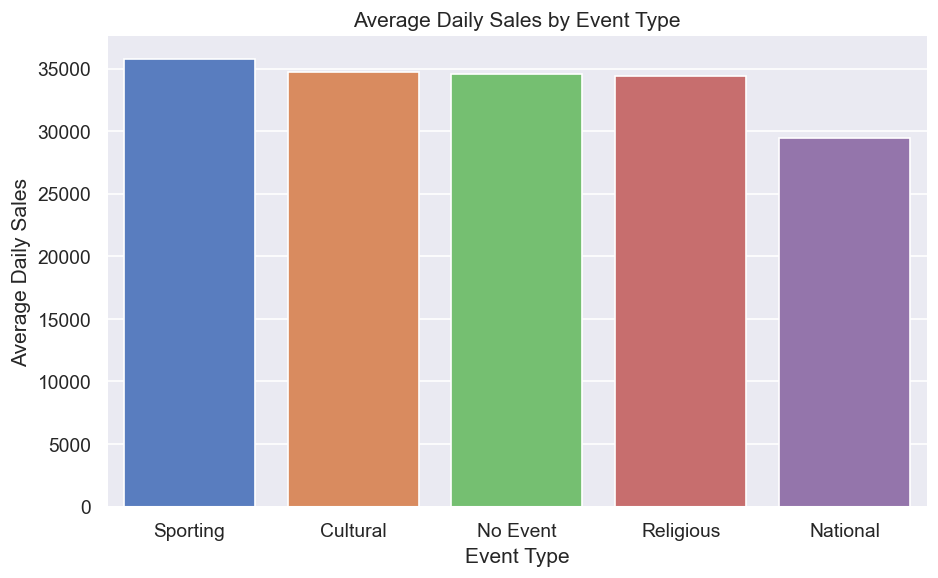

In [33]:
# nan fill with 'No Event' so they are not excluded
merged_df['event_type_1'] = merged_df['event_type_1'].fillna('No Event')

# total sales per day merged with event type, we get daily totals since we want average daily sales by event type 
daily_sales = (
    merged_df.groupby(['date', 'event_type_1'])['sales'].sum().reset_index()
)

# average across all days of each event type
event_sales = (
    daily_sales.groupby('event_type_1')['sales'].mean().sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=event_sales,
    x='event_type_1',
    y='sales',
    hue = 'event_type_1'
)
plt.title('Average Daily Sales by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Average Daily Sales')
plt.tight_layout()
plt.show()



The differences between event types are minimal. The overall pattern suggests that special events may not cause significant sales spikes. Sporting events record the highest average daily sales, slightly exceeding the no event baseline. National events show the lowest average sales, due to Christmas and Thanksgiving, when stores are closed or operate on reduced hours.
This analysis also highlights the distinction between invalid and valid missing data. The null values in the event fields do not indicate data quality issues. They represent days on which no special event occurred. However, these observations should be retained because removing them would delete valid records and skew the demand patterns.


This is an example of valid missing data vs invalid missing data. In this case, NaNs are not errors; they are valid observations, and should not be dropped. 


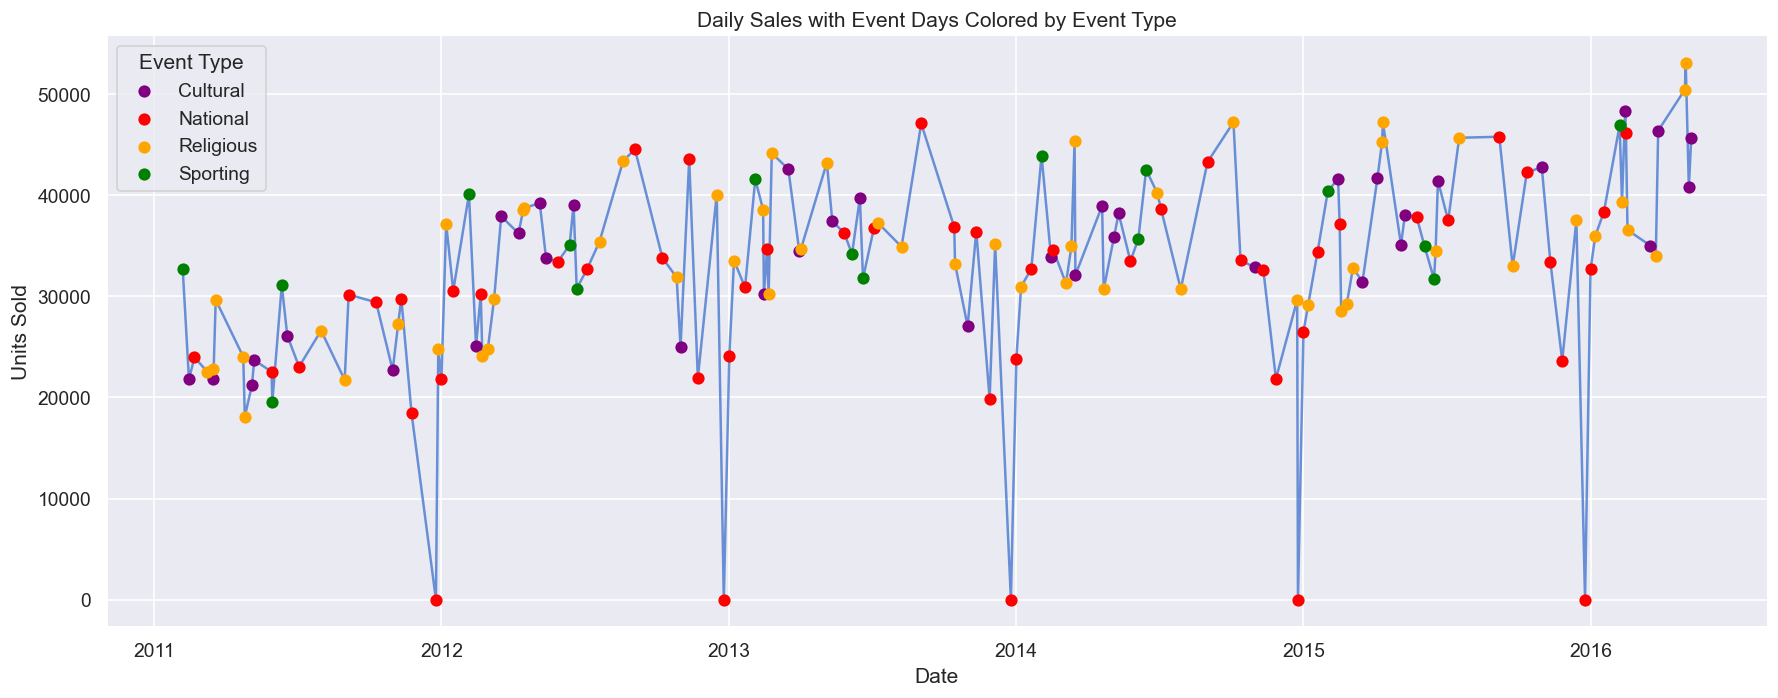

In [34]:
# get total daily sales
daily_sales = (
    merged_df.groupby(['date', 'event_name_1'])['sales'].sum().reset_index()
)

# separate out the event days for the scatter overlay
event_days = daily_sales[daily_sales['event_name_1'].notna()]

# color mapping for each event type
colors = {
    'Sporting':  'green',
    'Religious': 'orange',
    'National':  'red',
    'Cultural':  'purple'
}

# map event types onto event_days so we can color by event
event_days = event_days.merge(
    merged_df[['date', 'event_name_1', 'event_type_1']].drop_duplicates(),
    on=['date', 'event_name_1'],
    how='left'
)

plt.figure(figsize=(15, 6))

# line for all days
plt.plot(
    pd.to_datetime(daily_sales['date']),
    daily_sales['sales'],
    alpha=0.8
)

# scatter points colored by event type
for event_type, group in event_days.groupby('event_type_1'):
    plt.scatter(
        pd.to_datetime(group['date']),
        group['sales'],
        color=colors.get(event_type, 'gray'),
        s=40,
        label=event_type,
        zorder=5
    )

plt.title('Daily Sales with Event Days Colored by Event Type')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend(title='Event Type')
plt.tight_layout()
plt.show()


The chart shows an upward trend in daily sales over time, with event day sales rising from 20,000 to 30,000 units in 2011 to over 40,000 units by 2016. This suggests that long-term growth has a greater impact on sales than events alone.
Differences across event types are relatively small, though Sporting and Religious events tend to be associated with higher sales. National events show the greatest variability and include several instances of near-zero sales, likely corresponding to major holidays such as Christmas, when stores are closed. 

Overall, the findings suggest that while event type has some influence on sales, its impact is relatively minor compared to overall demand trends. Event variables should be modeled by event type rather than as a simple yes/no flag.



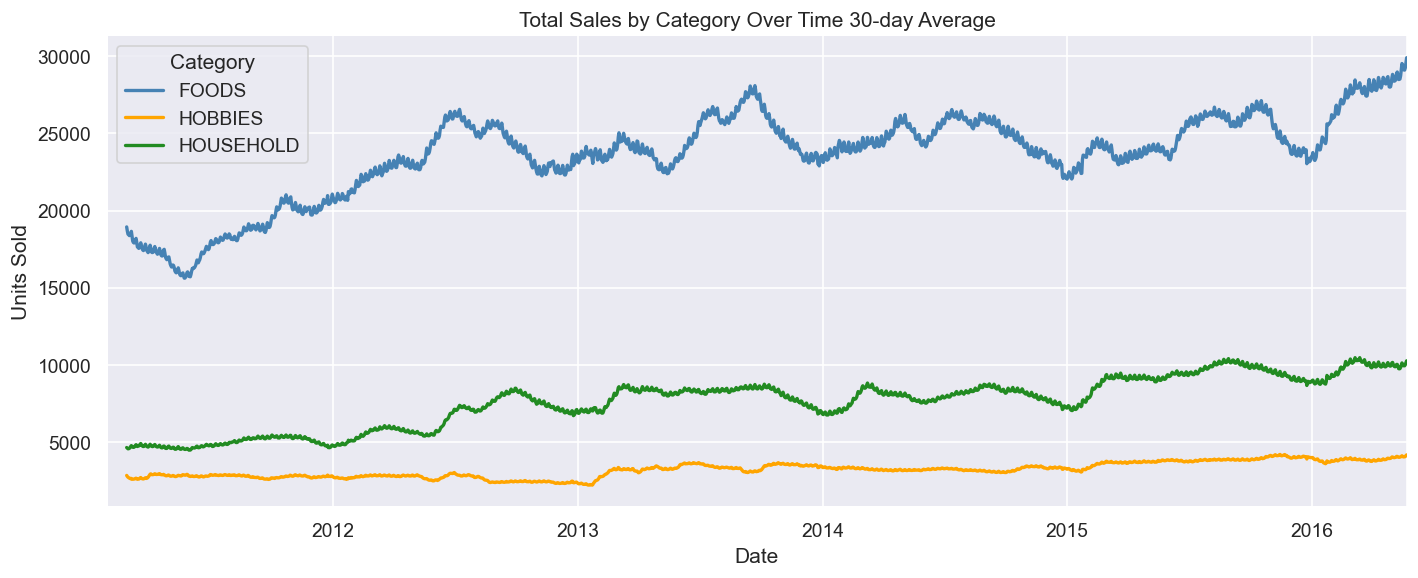

In [39]:
# make sure date is datetime
merged_df['date'] = pd.to_datetime(merged_df['date'])

# group by date and category, sum sales, then pivot so each category becomes its own column
# then apply 30-day rolling average to smooth daily spikes
category_sales = (
    merged_df.groupby(['date', 'cat_id'])['sales']
    .sum()
    .unstack()              
    .rolling(30).mean()     
)

plt.figure(figsize=(12, 5))


category_sales['FOODS'].plot(
    color='steelblue',
    linewidth=2,
    label='FOODS'
)
category_sales['HOBBIES'].plot(
    color='orange',
    linewidth=2,
    label='HOBBIES'
)
category_sales['HOUSEHOLD'].plot(
    color='forestgreen',
    linewidth=2,
    label='HOUSEHOLD'
)

plt.title('Total Sales by Category Over Time 30-day Average')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

The category breakdown shows that FOODS leads in total sales by  a large margin and shows the strongest growth trend during the period. HOUSEHOLD follows a similar seasonal pattern to FOODS, but at a smaller volume. HOBBIES is the smallest category and exhibits the most stable trend.